# Разработка A/B-тестирования и анализ результатов

## Описание данных

Данные содержатся в 3 таблицах:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. 


Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [1]:
# Импортируем библиотеки
import pandas as pd
# Выгружаем данные в переменную sessions_history
sessions_history = pd.read_csv('https://.../sessions_project_history.csv') 
# Выводим первые пять строк датафрейма sessions_history
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными

In [2]:
# Рассчитываем для каждого уникального пользователя количество сессий
session_count = sessions_history.groupby('user_id')['session_id'].count().reset_index()
session_count.sort_values(by='session_id', ascending = False)

,user_id,session_id
8948,10E0DEFC1ABDBBE0,10
55627,6A73CB5566BB494D,10
72346,8A60431A825D035B,9
109383,D11541BAC141FB94,9
47956,5BCFE7C4DCC148E9,9
...,...,...
15859,1DF13BB1953B3497,1
51449,628502A3CE7E0A3C,1
15853,1DEEF40DEFBD0C65,1
89905,AC08479B7472C628,1


In [3]:
# Выводим данные для пользователя с наибольшим количеством сессий
sessions_history[sessions_history['user_id'] == '10E0DEFC1ABDBBE0']

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций

In [4]:
# Меняем тип данных для столбца session_date
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

In [5]:
# Агрегируем данные по дням
registration_change = sessions_history.groupby('session_date').agg({'user_id': 'nunique', 'registration_flag': 'sum'}).reset_index()
registration_change

,session_date,user_id,registration_flag
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


In [6]:
# Импорт библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

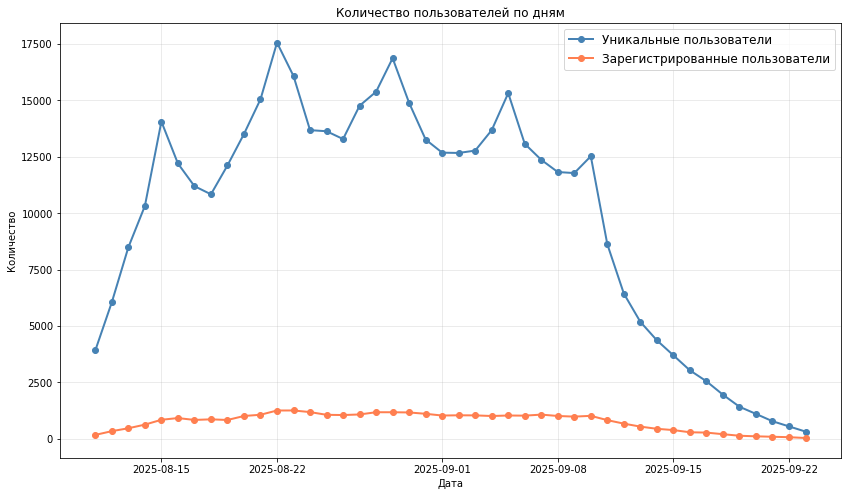

In [7]:
# Выводим график динамики количества пользователей по дням
plt.figure(figsize=(14, 8))
plt.plot(registration_change['session_date'], 
         registration_change['user_id'], 
         marker='o', linewidth=2, markersize=6, color='steelblue',
         label='Уникальные пользователи')

plt.plot(registration_change['session_date'], 
         registration_change['registration_flag'],
         marker='o', linewidth=2, markersize=6, color='coral',
         label='Зарегистрированные пользователи')

plt.title('Количество пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.show()

In [8]:
# Добавляем столбец с долей зарегистрированных пользователей
registration_change['registration_share'] = round((registration_change['registration_flag'] / registration_change['user_id']), 4) * 100
registration_change.head()

,session_date,user_id,registration_flag,registration_share
0,2025-08-11,3919,169,4.31
1,2025-08-12,6056,336,5.55
2,2025-08-13,8489,464,5.47
3,2025-08-14,10321,625,6.06
4,2025-08-15,14065,840,5.97


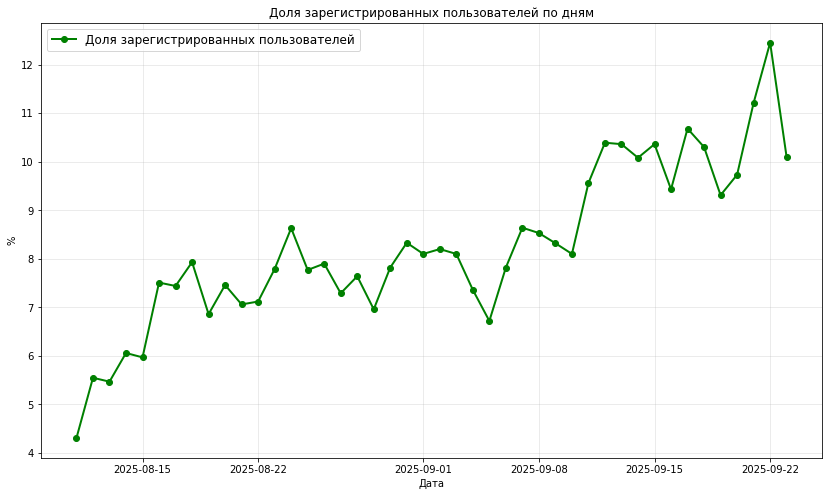

In [9]:
# Выводим график динамики доли зарегестрированных пользователей по дням
plt.figure(figsize=(14, 8))
plt.plot(registration_change['session_date'], 
         registration_change['registration_share'], 
         marker='o', linewidth=2, markersize=6, color='green',
         label='Доля зарегистрированных пользователей')

plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('%')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.show()

#### 1.4. Анализ числа просмотренных страниц

In [ ]:
# Рассчитываем количество сессий для каждого значения количества просмотренных страниц
session_page_count = sessions_history.groupby('page_counter')['session_id'].count().reset_index()
session_page_count

In [ ]:
# Выводим диаграмму 
plt.figure(figsize=(10, 6))
plt.bar(session_page_count['page_counter'],
        session_page_count['session_id']
)
plt.title('Колличество сессий для просмотров страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

In [12]:
# Создаём функцию для определения успешных сессий
def check_4_and_more(x):
    if x >= 4:
        return True
    else:
        return False

In [13]:
# Создаём столбец, в котором отмечаем успешные сессии
sessions_history['good_session'] = sessions_history['page_counter'].apply(check_4_and_more)

In [14]:
# Агрегируем данные по дням
session_count_change = sessions_history.groupby('session_date').agg({'session_id': 'count', 'good_session': 'sum'}).reset_index()
session_count_change['good_sessions_share'] = round((session_count_change['good_session'] / session_count_change['session_id']), 4) * 100
session_count_change.head()

,session_date,session_id,good_session,good_sessions_share
0,2025-08-11,3919,1226,31.28
1,2025-08-12,6056,1829,30.20
2,2025-08-13,8489,2604,30.67
3,2025-08-14,10321,3262,31.61
4,2025-08-15,14065,4289,30.49


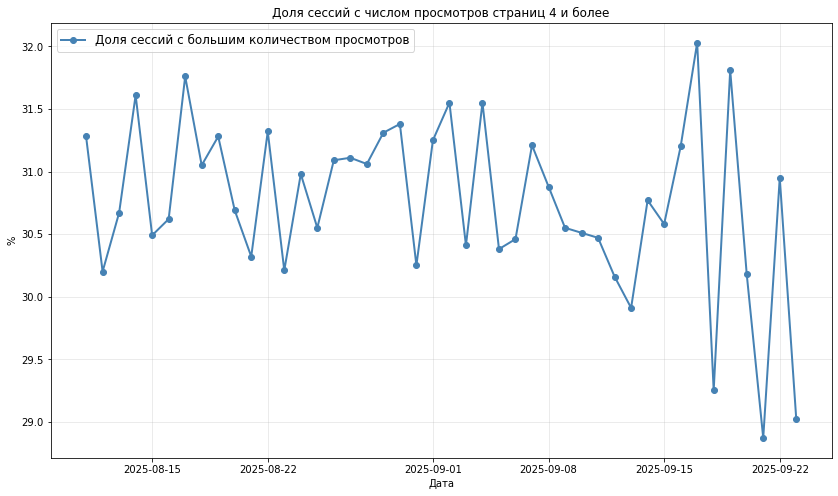

In [15]:
# Выводим график динамики доли успешных сессий
plt.figure(figsize=(14, 8))
plt.plot(session_count_change['session_date'], 
         session_count_change['good_sessions_share'], 
         marker='o', linewidth=2, markersize=6, color='steelblue',
         label='Доля сессий с большим количеством просмотров')

plt.title('Доля сессий с числом просмотров страниц 4 и более')
plt.xlabel('Дата')
plt.ylabel('%')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.show()

### 2. Подготовка к тесту

#### 2.1 Формулировка нулевой и альтернативной гипотез

**Нулевая гипотеза (Н0):** внедрение нового рекомендательного алгоритма не повлияет на количество успешных сессий для всех пользователей приложения.

**Альтернативная гипотеза (Н1):** внедрение нового рекомендательного алгоритма увеличит количество успешных сессий для всех пользователей приложения.

*Под успешными сессиями понимаются сессии, в которых просмотрены 4 и более страницы.*

#### 2.2. Расчёт размера выборки

In [16]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.3. Расчёт длительности A/B-теста

In [17]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = registration_change['user_id'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((41040 * 2) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

In [18]:
# Выгружаем данные
sessions_test_part = pd.read_csv('https://.../sessions_project_test_part.csv') 
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [19]:
# Считаем количество пользователей за один день проведения теста
total_users_part = sessions_test_part['user_id'].nunique()
group_A_part = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
group_B_part = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()
print(f'Количество пользователей в А/В-тесте: {total_users_part}')
print(f'Количество пользователей в группе А: {group_A_part}')
print(f'Количество пользователей в группе В: {group_B_part}')

Количество пользователей в А/В-тесте: 2943
Количество пользователей в группе А: 1477
Количество пользователей в группе В: 1466


In [20]:
# Считаем доли пользователей в группах
group_A_share = 100 * (group_A_part / total_users_part)
group_B_share = 100 * (group_B_part / total_users_part)
P = 100 * ((group_A_part - group_B_part) / group_A_part)
print(f'Доля пользователей в группе А: {group_A_share}')
print(f'Доля пользователей в группе В: {group_B_share}')
print(f'Процентная разница между группами: {P}') 

Доля пользователей в группе А: 50.18688413183826
Доля пользователей в группе В: 49.81311586816174
Процентная разница между группами: 0.7447528774542992


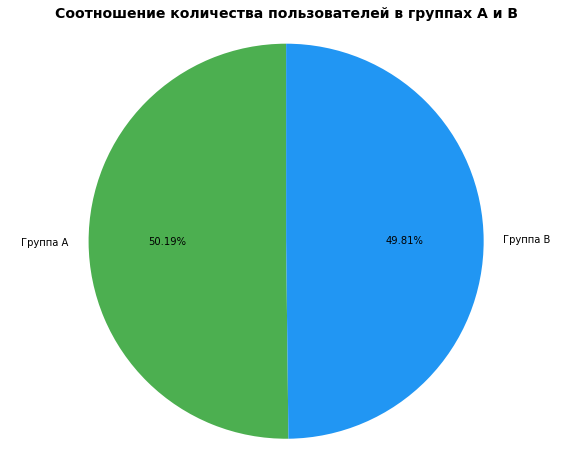

In [21]:
# Строим круговую диаграму соотношения пользователей в группах
pie_sizes = [group_A_share, group_B_share]

plt.figure(figsize=(10, 8))
labels = ['Группа А', 'Группа В']
colors = ['#4CAF50', '#2196F3']
plt.pie(pie_sizes, labels=labels, autopct='%1.2f%%', colors=colors, 
         startangle=90)
plt.title('Соотношение количества пользователей в группах A и B', fontsize=14, fontweight='bold')
plt.axis('equal')  
plt.show()

#### 3.2. Проверка пересечений пользователей

In [22]:
# Считаем количество пересекающихся пользователей
users_group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
users_group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']
intersection = list(set(users_group_A) & set(users_group_B))
print (f'Количество пересекающихся пользователей: {len(intersection)}') 

Количество пересекающихся пользователей: 0


#### 3.3. Равномерность разделения пользователей по устройствам

In [23]:
# Разделяем датафрейм на группы
sessions_test_part_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
sessions_test_part_B = sessions_test_part[sessions_test_part['test_group'] == 'B']
# Агрегируем данные по типам устройств
device_share_group_A = sessions_test_part_A.groupby('device')['user_id'].nunique().reset_index()
device_share_group_B = sessions_test_part_B.groupby('device')['user_id'].nunique().reset_index()
device_share_group_A['device_share'] = round((device_share_group_A['user_id'] / device_share_group_A['user_id'].sum()), 4) * 100
device_share_group_B['device_share'] = round((device_share_group_B['user_id'] / device_share_group_B['user_id'].sum()), 4) * 100
display(device_share_group_A, device_share_group_B)

,device,user_id,device_share
0,Android,656,44.41
1,Mac,156,10.56
2,PC,369,24.98
3,iPhone,296,20.04


,device,user_id,device_share
0,Android,668,45.57
1,Mac,148,10.10
2,PC,381,25.99
3,iPhone,269,18.35


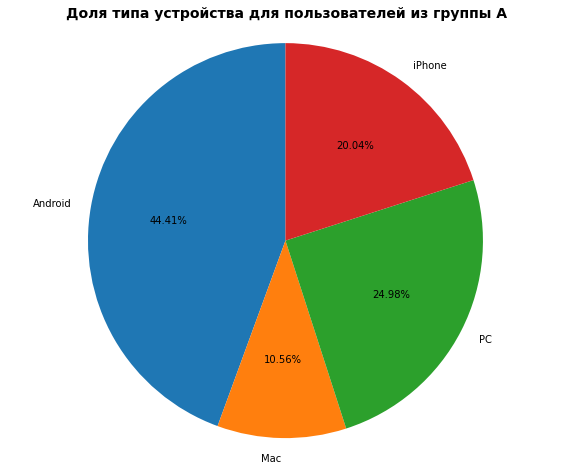

In [24]:
# Строим круговую диаграмму доли каждого типа устройства для пользователей из группы A
plt.figure(figsize=(10, 8))
plt.pie(device_share_group_A['device_share'], labels=device_share_group_A['device'], autopct='%1.2f%%', 
         startangle=90)
plt.title('Доля типа устройства для пользователей из группы А', fontsize=14, fontweight='bold')
plt.axis('equal')  
plt.show()

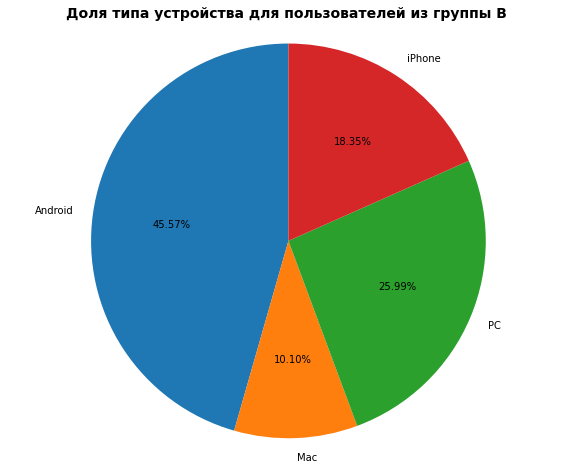

In [25]:
# Строим круговую диаграмму доли каждого типа устройства для пользователей из группы В
plt.figure(figsize=(10, 8))
plt.pie(device_share_group_B['device_share'], labels=device_share_group_B['device'], autopct='%1.2f%%', 
         startangle=90)
plt.title('Доля типа устройства для пользователей из группы B', fontsize=14, fontweight='bold')
plt.axis('equal')  
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам

In [26]:
# Агрегируем данные по регионам
region_share_group_A = sessions_test_part_A.groupby('region')['user_id'].nunique().reset_index()
region_share_group_B = sessions_test_part_B.groupby('region')['user_id'].nunique().reset_index()
region_share_group_A['region_share'] = round((region_share_group_A['user_id'] / region_share_group_A['user_id'].sum()), 4) * 100
region_share_group_B['region_share'] = round((region_share_group_B['user_id'] / region_share_group_B['user_id'].sum()), 4) * 100
display(region_share_group_A, region_share_group_B)

,region,user_id,region_share
0,CIS,644,43.60
1,EU,224,15.17
2,MENA,609,41.23


,region,user_id,region_share
0,CIS,645,44.0
1,EU,217,14.8
2,MENA,604,41.2


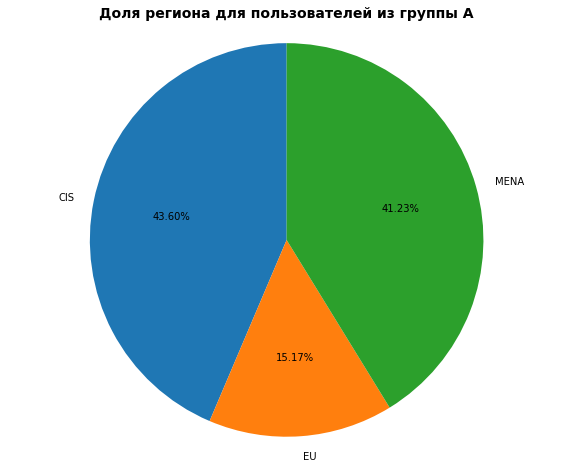

In [27]:
# Строим круговую диаграмму доли региона для пользователей из группы A
plt.figure(figsize=(10, 8))
plt.pie(region_share_group_A['region_share'], labels=region_share_group_A['region'], autopct='%1.2f%%', 
         startangle=90)
plt.title('Доля региона для пользователей из группы А', fontsize=14, fontweight='bold')
plt.axis('equal')  
plt.show()

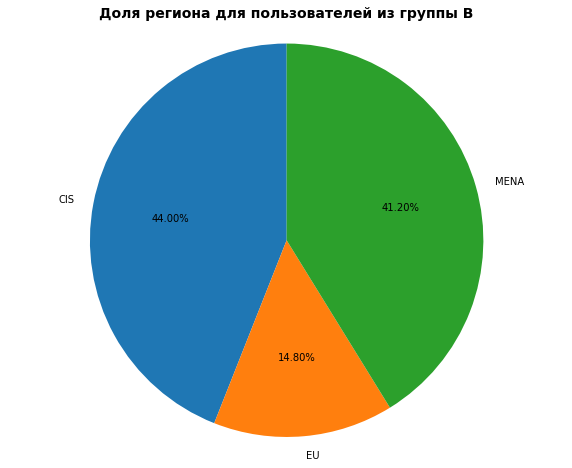

In [28]:
# Строим круговую диаграмму доли региона для пользователей из группы В
plt.figure(figsize=(10, 8))
plt.pie(region_share_group_B['region_share'], labels=region_share_group_B['region'], autopct='%1.2f%%', 
         startangle=90)
plt.title('Доля региона для пользователей из группы B', fontsize=14, fontweight='bold')
plt.axis('equal')  
plt.show()

#### 3.5. Вывод после проверки A/B-теста

**По результатам мониторинга проведения А/В-теста можно выделить следующее:**
- Количество пользователей в группах для тестирования сопостовимы: группа А - 1477, группа Б - 1466, что составляет 50,19% и 49,81% от общего числа пользователей за период проводимого мониторинга.
- Выборки независимы, пересечение пользователей из тестовой и контрольной группы не обнаружено.
- Распределение пользователей тестовой и контрольной групп по устройствам и регионам в целом равномерное, различия в распределениях незначительны.

Таким образом, можно сделать вывод, что А/В-тест проходит корректно, нарушения в проведении теста не наблюдаются.

### 4. Проверка результатов A/B-теста

#### 4.1. Получение результатов теста и подсчёт основной метрики

In [29]:
# Выгружаем данные
sessions_test = pd.read_csv('https://.../sessions_project_test.csv')
sessions_test['good_session'] = sessions_test['page_counter'].apply(check_4_and_more)
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,False
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,False
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,False
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,False
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,False


In [30]:
# Считаем количество пользователей, принявших участие в эксперименте
total_users = sessions_test['user_id'].nunique()
group_A = sessions_test[sessions_test['test_group'] == 'A']['user_id'].nunique()
group_B = sessions_test[sessions_test['test_group'] == 'B']['user_id'].nunique()
print(f'Количество пользователей в А/В-тесте: {total_users}')
print(f'Количество пользователей в группе А: {group_A}')
print(f'Количество пользователей в группе В: {group_B}')

Количество пользователей в А/В-тесте: 30579
Количество пользователей в группе А: 15163
Количество пользователей в группе В: 15416


#### 4.2. Проверка корректности результатов теста

In [31]:
# Делим датафрейм на две группы
sessions_test_A = sessions_test[sessions_test['test_group'] == 'A']
sessions_test_B = sessions_test[sessions_test['test_group'] == 'B']

In [32]:
# Агрегируем данные по дням
daily_sessions_A = sessions_test_A.groupby('session_date')['session_id'].nunique().reset_index()
daily_sessions_B = sessions_test_B.groupby('session_date')['session_id'].nunique().reset_index()
display(daily_sessions_A, daily_sessions_B)

,session_date,session_id
0,2025-10-14,1502
1,2025-10-15,2235
2,2025-10-16,3280
3,2025-10-17,4089
4,2025-10-18,5013
5,2025-10-19,6535
6,2025-10-20,5837
7,2025-10-21,3927
8,2025-10-22,3083
9,2025-10-23,2470


,session_date,session_id
0,2025-10-14,1628
1,2025-10-15,2283
2,2025-10-16,3241
3,2025-10-17,4054
4,2025-10-18,5059
5,2025-10-19,6779
6,2025-10-20,6089
7,2025-10-21,3981
8,2025-10-22,3111
9,2025-10-23,2548


In [33]:
# Применяем t-тест Стьюдента для выявления статистической значимости
from scipy import stats as st
import numpy as np

daily_sessions_g1 = daily_sessions_A['session_id']
daily_sessions_g2 = daily_sessions_B['session_id']

alpha = 0.05
results = st.ttest_ind(
    daily_sessions_g1,
    daily_sessions_g2,
    alternative='two-sided')
pvalue = results.pvalue

print(f'Значение p-value: {pvalue}')
if pvalue < alpha:
      print('Отвергаем нулевую гипотезу')
else:
      print('Не получилось отвергнуть нулевую гипотезу')

Значение p-value: 0.938219304859116
Не получилось отвергнуть нулевую гипотезу


**Результат статистического теста:**

Двухвыборочный t-тест Стьюдента, применённый к выборочным данным количества дневных сессий двух групп, показал значение p-value: 0.938219304859116, что значительно больше уровня статистической значимости 0.05. В этой связи можно утверждать, что количество уникальных дневных сессий в двух выборках в целом не различается, а имеющие различия статистически не значимыми.

#### 4.3. Сравнение доли успешных сессий

In [34]:
# Рассчитываем долю успешных сессий для выборок А и В
good_session_share_A = round(sessions_test_A['good_session'].mean() * 100, 2)
good_session_share_B = round(sessions_test_B['good_session'].mean() * 100, 2)
difference = round((good_session_share_B - good_session_share_A), 2)
print(f'Доля успешных сессий выборки А: {good_session_share_A} %')
print(f'Доля успешных сессий выборки B: {good_session_share_B} %')
print(f'Разница между выборками составляет {difference} %')

Доля успешных сессий выборки А: 30.77 %
Доля успешных сессий выборки B: 31.83 %
Разница между выборками составляет 1.06 %


#### 4.4. Насколько статистически значимо изменение ключевой метрики

**Выбор статистического теста**

В связи с тем, что в рамках продуктовой гипотезы необходимо выявить разницу между долями в двух группах, для определения статистической значимости будет применяться Z-тест пропорций.

In [35]:
# Проверяем, достаточно ли данных для проведения z-теста пропорций
n_a = len(sessions_test_A['session_id'])
n_b = len(sessions_test_B['session_id'])
m_a = sum(sessions_test_A['good_session'])
m_b = sum(sessions_test_B['good_session'])
p_a = sessions_test_A['good_session'].mean()
p_b = sessions_test_B['good_session'].mean()

# Проверяем предпосылку о достаточном количестве данных
if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): 
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

Предпосылка о достаточном количестве данных выполняется!


In [36]:
# Применяем z-тест пропорций
from statsmodels.stats.proportion import proportions_ztest

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)

print(f'pvalue={p_value_ztest}')

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение!')
else:
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.0001574739988036123
Нулевая гипотеза не находит подтверждения!


**Результат статистического теста:**

Z-тест пропорций, применённый к долям успешных сессий двух групп, показал значение p-value: 0.0001574739988036123, что значительно меньше уровня статистической значимости 0.05. В этой связи можно утверждать, что разница между долями успешных сессий в группах статистически значима и доля в тестируемой группе больше, чем доля в контрольной.

#### 4.5. Вывод по результатам A/B-эксперимента

**Результат проведённого А/В-теста**

Исследование было проведено в целях изучения влияния нового рекомендательного алгоритма приложения на заинтересованность пользователей в просмотре контента. Для этого были сформулированы следующие продуктовые гипотезы:

Нулевая гипотеза (Н0): внедрение нового рекомендательного алгоритма не повлияет на количество успешных сессий для всех пользователей приложения.

Альтернативная гипотеза (Н1): внедрение нового рекомендательного алгоритма увеличит количество успешных сессий для всех пользователей приложения.

*Под успешными сессиями понимаются сессии, где пользователем было просмотрено 4 и более страниц.*

В рамках проведения тестирования пользователи были разделены на 2 группы: группа А - контрольная группа (без изменений в рекомендательных алгоритмах), группа В - тестируемая группа (пользовались новым рекомендательным алгоритмом).
Исследование проводилось в течении 20 дней в период с 2025-10-14 по 2025-11-02. Всего в тестировании приняло участие 30579 пользователей (группа А - 15163, группа В - 15416). Стоит отметить, что выборки для проведения теста являются недостаточными. Для более корректного результата необходимо, чтобы количество пользователей в одной группе составляло не менее 40410 человек.

По результатам проведённого А/В-теста было выявлено увеличение доли успешных сессий в группе В по сравнению с группой А:  

- Доля успешных сессий выборки А: 30.77 %
- Доля успешных сессий выборки B: 31.83 %
- Разница между выборками составляет 1.06 %

Таким образом, внеднерние нового рекомендательного алгоритма привело к росту доли успешных сессий в тестируемой группе на 1.06 % по сравнению с контрольной.

Вместе с этим, был проведён статистический тест результатов эксперимента. В качестве статистического теста был выбран Z-тест пропорций, установлен уровень статистической значимости в 0.05.

Z-тест пропорций, применённый к долям успешных сессий двух групп, показал значение p-value: 0.0001574739988036123, что значительно меньше уровня статистической значимости 0.05. В этой связи можно утверждать, что разница между долями успешных сессий в группах статистически значима и доля в тестируемой группе больше, чем доля в контрольной.

Проведенное исследование показало, что применение нового рекомендательного алгоритма увеличивает заинтересованность пользователей приложения в контенте, что наблюдается в увеличении количества успешных сессий. Для определения целесообразности применения нового рекомендательного алгоритма в приложении необходимо обратить внимание на следующие факторы: экономическая эффективность внедрения, риск ухудшения пользовательского опыта (уменьшение количества пользователей, их активности и т.д.), стабильность работы приложения при внедрении нововведений. В этой связи, в дополнение к проведённому исследованию, рекомендуется изучить влияние вышеуказанных факторов на внедрение нового алгоритма. 